In [31]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
from typing import TypedDict
from dotenv import load_dotenv
import os

load_dotenv()

True

In [40]:
llm = HuggingFaceEndpoint(
    repo_id="google/gemma-4-31B-it",
    task="text-generation",
)

chat = ChatHuggingFace(llm=llm)

In [41]:
class LLMState(TypedDict):
    input:str
    output:str
    memory:dict[str,str]
    

In [59]:
def askLLM(state:LLMState)->LLMState:
    question=f"""So you are a personal assistant who have to solve this query: {state["input"]} and the 
       previous queries and their responses are: {state["memory"]} , which you will use to answer the current query.
       If you don't have enough information to answer the query, say "I don't know" and ask for more information.
       Otherwise, provide a concise and accurate answer to the query.
    """
    response=chat.invoke(question)
    state["output"]=response.content
    state["memory"][question] = state["output"]
    return state

In [60]:
from langgraph.types import interrupt

def human_input_node(state:LLMState)->LLMState:
    #wait for user input after the LLM response if user types "continue " then continue the loop otherwise terminate the workflow
    input = interrupt("Type your question or type'exit' to stop")
    state["input"]=input
    return state

In [61]:
def should_continue(state: LLMState):
    if LLMState["input"] == "exit":
        return "end"
    else:
        return "loop"

In [62]:
graph=StateGraph(LLMState)

graph.add_node('askLLM',askLLM)
graph.add_node("human_input_node", human_input_node)

graph.add_edge(START, "askLLM")
graph.add_edge("askLLM", "human_input_node")

graph.add_conditional_edges(
    "human_input_node",
    should_continue,
    {
        "loop": "askLLM",
        "end": END
    }
)


workflow=graph.compile()



In [67]:
state = {
    "input": "Hello assistant",
    "output": "",
    "memory": {}
}

while True:
    result = workflow.invoke(state)
    print(f"Response: {result['output']}")

    # Handle interrupt
    if "__interrupt__" in result:
        user_input = input(result["__interrupt__"][0].value)
        print(f"Query: {user_input}")
        if user_input == "exit":
            break

        # Clean state (remove interrupt key)
        state = {
            "input": user_input,
            "output": result.get("output", ""),
            "memory": result.get("memory", {})
        }
        

    else:
        print("No interrupt, ending workflow.")
        

Response: I am ready. Please provide the **previous queries and their responses** and the **current query** you would like me to answer.
Query: hi
Response: Hello! How can I help you today?
Query: what is my name
Response: I don't know. Could you please tell me your name?
Query: can you tell me the {state["memory"]} that you got as input in this prompt
Response: The `{state["memory"]}` provided in the input is a dictionary containing the history of three previous interactions:

1.  **Query:** "Hello assistant" $\rightarrow$ **Response:** "I am ready. Please provide the previous queries and their responses and the current query you would like me to answer."
2.  **Query:** "hi" $\rightarrow$ **Response:** "Hello! How can I help you today?"
3.  **Query:** "what is my name" $\rightarrow$ **Response:** "I don't know. Could you please tell me your name?"
Query: exit


In [68]:
print(result)

{'input': 'can you tell me the {state["memory"]} that you got as input in this prompt', 'output': 'The `{state["memory"]}` provided in the input is a dictionary containing the history of three previous interactions:\n\n1.  **Query:** "Hello assistant" $\\rightarrow$ **Response:** "I am ready. Please provide the previous queries and their responses and the current query you would like me to answer."\n2.  **Query:** "hi" $\\rightarrow$ **Response:** "Hello! How can I help you today?"\n3.  **Query:** "what is my name" $\\rightarrow$ **Response:** "I don\'t know. Could you please tell me your name?"', 'memory': {'So you are a personal assistant who have to solve this query: Hello assistant and the \n       previous queries and their responses are: {} , which you will use to answer the current query.\n       If you don\'t have enough information to answer the query, say "I don\'t know" and ask for more information.\n       Otherwise, provide a concise and accurate answer to the query.\n    

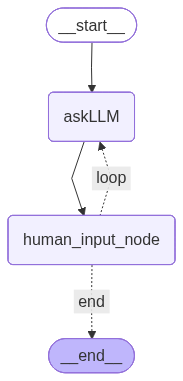

In [69]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())